In [2]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install paddlepaddle paddleocr


Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---------------------------------------------
# 1. Import Required Libraries
# ---------------------------------------------
import cv2
import pytesseract
from paddleocr import PaddleOCR
import pandas as pd
import time

/root/pytesseract/myenv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


In [5]:
# ---------------------------------------------
# 2. Setup OCR Models
# ---------------------------------------------
# Initialize PaddleOCR (English)
paddle_ocr = PaddleOCR(use_angle_cls=True, lang='en')

[2025/05/09 14:49:53] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

In [6]:
# ---------------------------------------------
# 3. Define Image List
# ---------------------------------------------
image_folder = '/root/pytesseract/testData/'
image_names = [f'a{i}.jpg' for i in range(1, 16)]  # a1.jpg to a15.jpg

In [11]:
tess_words = len(text_tess.split())


In [12]:
tess_words

39

In [13]:
paddle_words = sum([len(line[1][0].split()) for line in result_paddle[0]])


In [14]:
paddle_words

27

In [15]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_angle_cls=True, lang='en')


[2025/05/09 14:20:48] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

In [16]:
import os


In [17]:
import os
import time
from PIL import Image
import pytesseract
from paddleocr import PaddleOCR


In [9]:
import os
import time
from PIL import Image


In [10]:
image_dir = '/root/pytesseract/testData'   # or whatever your images folder is


In [15]:
results = []

for img_name in image_names:
    img_path = os.path.join(image_folder, img_name)

    # Load image
    img_cv2 = cv2.imread(img_path)
    img_pil = Image.open(img_path)

    # --- Tesseract OCR ---
    start_time = time.time()
    text_tess = pytesseract.image_to_string(img_pil)
    tess_time = round(time.time() - start_time, 3)

    tess_chars = len(text_tess.replace("\n", "").replace(" ", ""))
    
    # Confidence from data output
    tess_data = pytesseract.image_to_data(img_pil, output_type=pytesseract.Output.DICT)
    tess_confidences = [int(conf) for conf in tess_data['conf'] if str(conf).strip() != '-1']
    avg_conf_tesseract = round((sum(tess_confidences) / len(tess_confidences)) / 100,2) if tess_confidences else 0

    #tess_avg_conf = round(sum(tess_confidences) / len(tess_confidences), 2) if tess_confidences else 0

    # --- PaddleOCR ---
    start_time = time.time()
    result_paddle = paddle_ocr.ocr(img_path, cls=True)
    paddle_time = round(time.time() - start_time, 3)

    paddle_chars = sum([len(line[1][0].replace(" ", "")) for line in result_paddle[0]])
    paddle_confidences = [line[1][1] for line in result_paddle[0]]
    paddle_avg_conf = round(sum(paddle_confidences) / len(paddle_confidences), 2) if paddle_confidences else 0

    # --- Save results ---
    results.append({
        'Image': img_name,
        'Tesseract_Chars': tess_chars,
        'Tesseract_Time': tess_time,
        'Tesseract_Conf': avg_conf_tesseract,
        'PaddleOCR_Chars': paddle_chars,
        'PaddleOCR_Time': paddle_time,
        'PaddleOCR_Conf': paddle_avg_conf
    })

[2025/05/09 14:55:42] ppocr DEBUG: dt_boxes num : 17, elapsed : 0.0427095890045166
[2025/05/09 14:55:42] ppocr DEBUG: cls num  : 17, elapsed : 0.037648916244506836
[2025/05/09 14:55:43] ppocr DEBUG: rec_res num  : 17, elapsed : 0.922062873840332
[2025/05/09 14:55:43] ppocr DEBUG: dt_boxes num : 18, elapsed : 0.07131838798522949
[2025/05/09 14:55:43] ppocr DEBUG: cls num  : 18, elapsed : 0.030650854110717773
[2025/05/09 14:55:44] ppocr DEBUG: rec_res num  : 18, elapsed : 0.9677338600158691
[2025/05/09 14:55:44] ppocr DEBUG: dt_boxes num : 16, elapsed : 0.0727994441986084
[2025/05/09 14:55:44] ppocr DEBUG: cls num  : 16, elapsed : 0.036699533462524414
[2025/05/09 14:55:45] ppocr DEBUG: rec_res num  : 16, elapsed : 0.9194698333740234
[2025/05/09 14:55:46] ppocr DEBUG: dt_boxes num : 18, elapsed : 0.0421292781829834
[2025/05/09 14:55:46] ppocr DEBUG: cls num  : 18, elapsed : 0.032212018966674805
[2025/05/09 14:55:47] ppocr DEBUG: rec_res num  : 18, elapsed : 0.9711382389068604
[2025/05/09 

In [16]:
import pandas as pd

# Convert results list to a dataframe
df_results = pd.DataFrame(results)

# Show the table
df_results

,Image,Tesseract_Chars,Tesseract_Time,Tesseract_Conf,PaddleOCR_Chars,PaddleOCR_Time,PaddleOCR_Conf
0,a1.jpg,167,0.170,0.78,179,1.008,0.96
1,a2.jpg,170,0.158,0.71,171,1.075,0.94
2,a3.jpg,186,0.173,0.82,181,1.034,0.94
3,a4.jpg,172,0.169,0.78,165,1.051,0.94
4,a5.jpg,159,0.176,0.77,157,0.969,0.95
5,a6.jpg,179,0.159,0.79,177,1.003,0.93
6,a7.jpg,177,0.179,0.68,181,1.017,0.93
7,a8.jpg,146,0.160,0.80,165,0.953,0.95
8,a9.jpg,173,0.151,0.73,176,0.907,0.94
9,a10.jpg,181,0.158,0.78,176,0.911,0.96


In [17]:
df_results.to_csv("ocr_rate_results.csv", index=False)


In [20]:
# Average confidence
avg_conf_tesseract = df_results['Tesseract_Conf'].mean()
avg_conf_paddle = df_results['PaddleOCR_Conf'].mean() 

# Average time
avg_time_tesseract = df_results['Tesseract_Time'].mean()
avg_time_paddle = df_results['PaddleOCR_Time'].mean()

print(f"Average Tesseract Confidence: {avg_conf_tesseract:.2f}")
print(f"Average PaddleOCR Confidence: {avg_conf_paddle:.2f}")
print(f"Average Tesseract Time: {avg_time_tesseract:.2f} seconds")
print(f"Average PaddleOCR Time: {avg_time_paddle:.2f} seconds")


Average Tesseract Confidence: 0.77
Average PaddleOCR Confidence: 0.94
Average Tesseract Time: 0.16 seconds
Average PaddleOCR Time: 0.98 seconds


In [22]:
# --- Standard Deviation Calculations ---
std_conf_tesseract = df_results['Tesseract_Conf'].std()
std_conf_paddle = df_results['PaddleOCR_Conf'].std()

std_time_tesseract = df_results['Tesseract_Time'].std()
std_time_paddle = df_results['PaddleOCR_Time'].std()

# --- Print Results ---
print(f"Standard Deviation of Tesseract Confidence: {std_conf_tesseract:.2f}")
print(f"Standard Deviation of PaddleOCR Confidence: {std_conf_paddle:.2f}")
print(f"Standard Deviation of Tesseract Time: {std_time_tesseract:.2f}")
print(f"Standard Deviation of PaddleOCR Time: {std_time_paddle:.2f}")


Standard Deviation of Tesseract Confidence: 0.04
Standard Deviation of PaddleOCR Confidence: 0.01
Standard Deviation of Tesseract Time: 0.01
Standard Deviation of PaddleOCR Time: 0.06


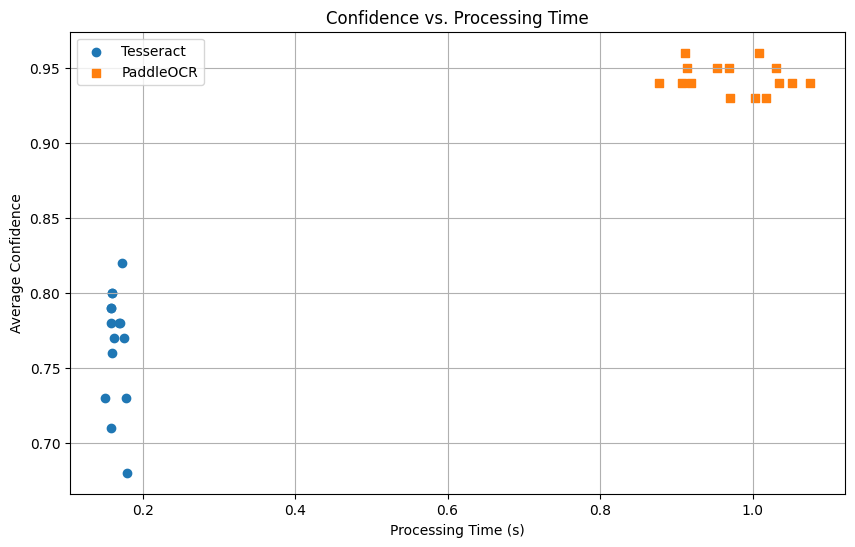

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_results["Tesseract_Time"], df_results["Tesseract_Conf"], label="Tesseract", marker='o')
plt.scatter(df_results["PaddleOCR_Time"], df_results["PaddleOCR_Conf"], label="PaddleOCR", marker='s')
plt.xlabel("Processing Time (s)")
plt.ylabel("Average Confidence")
plt.title("Confidence vs. Processing Time")
plt.legend()
plt.grid(True)
plt.show()


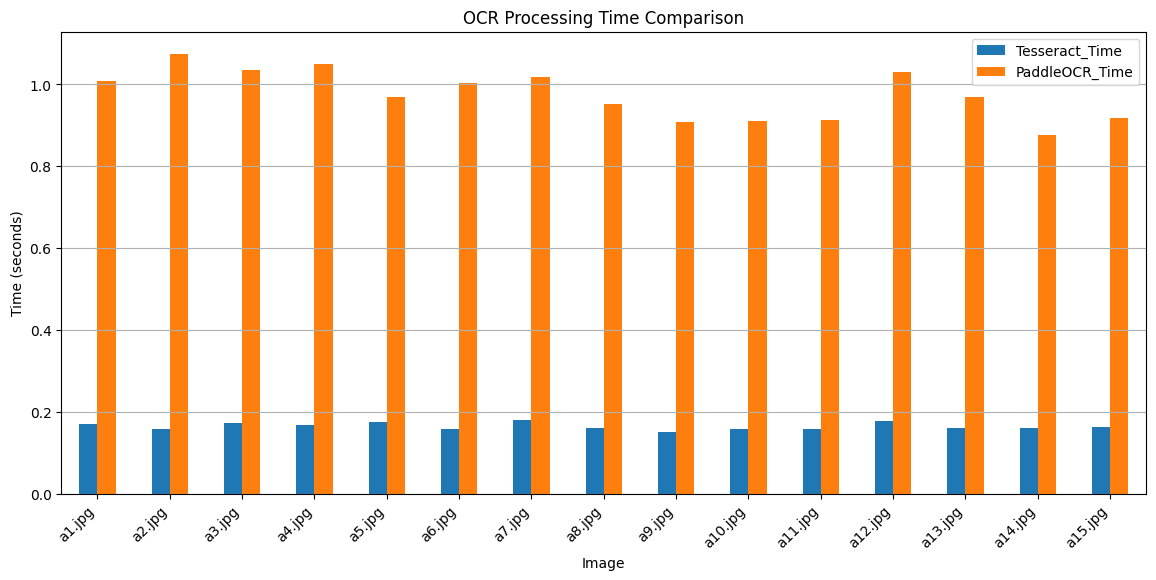

In [25]:
df_results.plot(x="Image", y=["Tesseract_Time", "PaddleOCR_Time"], kind="bar", figsize=(14, 6))
plt.title("OCR Processing Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()


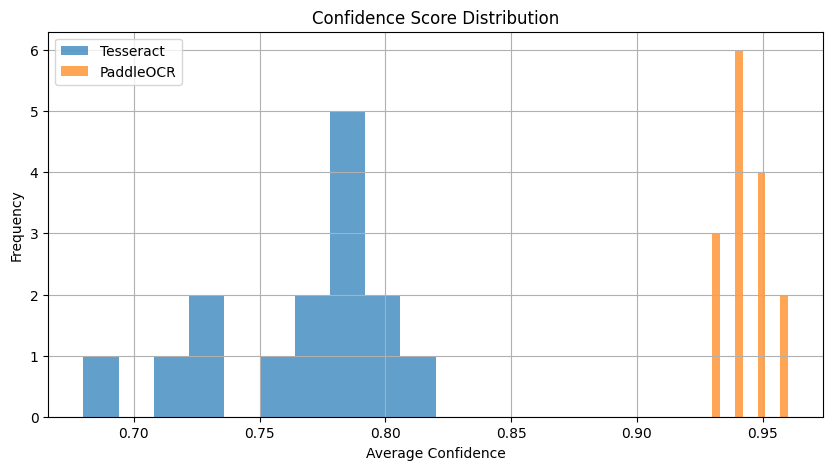

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(df_results["Tesseract_Conf"], bins=10, alpha=0.7, label="Tesseract")
plt.hist(df_results["PaddleOCR_Conf"], bins=10, alpha=0.7, label="PaddleOCR")
plt.xlabel("Average Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Score Distribution")
plt.legend()
plt.grid(True)
plt.show()


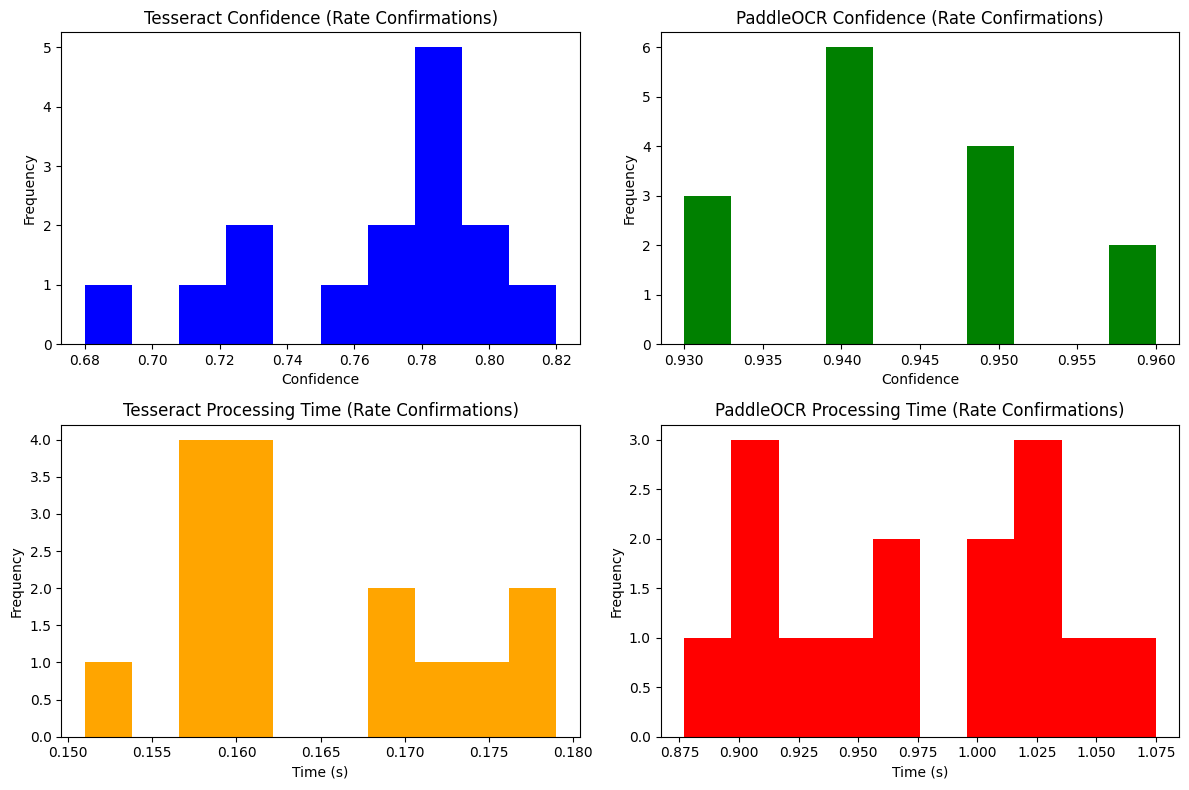

In [32]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame for rate confirmations

plt.figure(figsize=(12, 8))

# Tesseract Confidence
plt.subplot(2, 2, 1)
plt.hist(df_results['Tesseract_Conf'], bins=10, color='blue')
plt.title("Tesseract Confidence (Rate Confirmations)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

# PaddleOCR Confidence
plt.subplot(2, 2, 2)
plt.hist(df_results['PaddleOCR_Conf'], bins=10, color='green')
plt.title("PaddleOCR Confidence (Rate Confirmations)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

# Tesseract Processing Time
plt.subplot(2, 2, 3)
plt.hist(df_results['Tesseract_Time'], bins=10, color='orange')
plt.title("Tesseract Processing Time (Rate Confirmations)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency")

# PaddleOCR Processing Time
plt.subplot(2, 2, 4)
plt.hist(df_results['PaddleOCR_Time'], bins=10, color='red')
plt.title("PaddleOCR Processing Time (Rate Confirmations)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


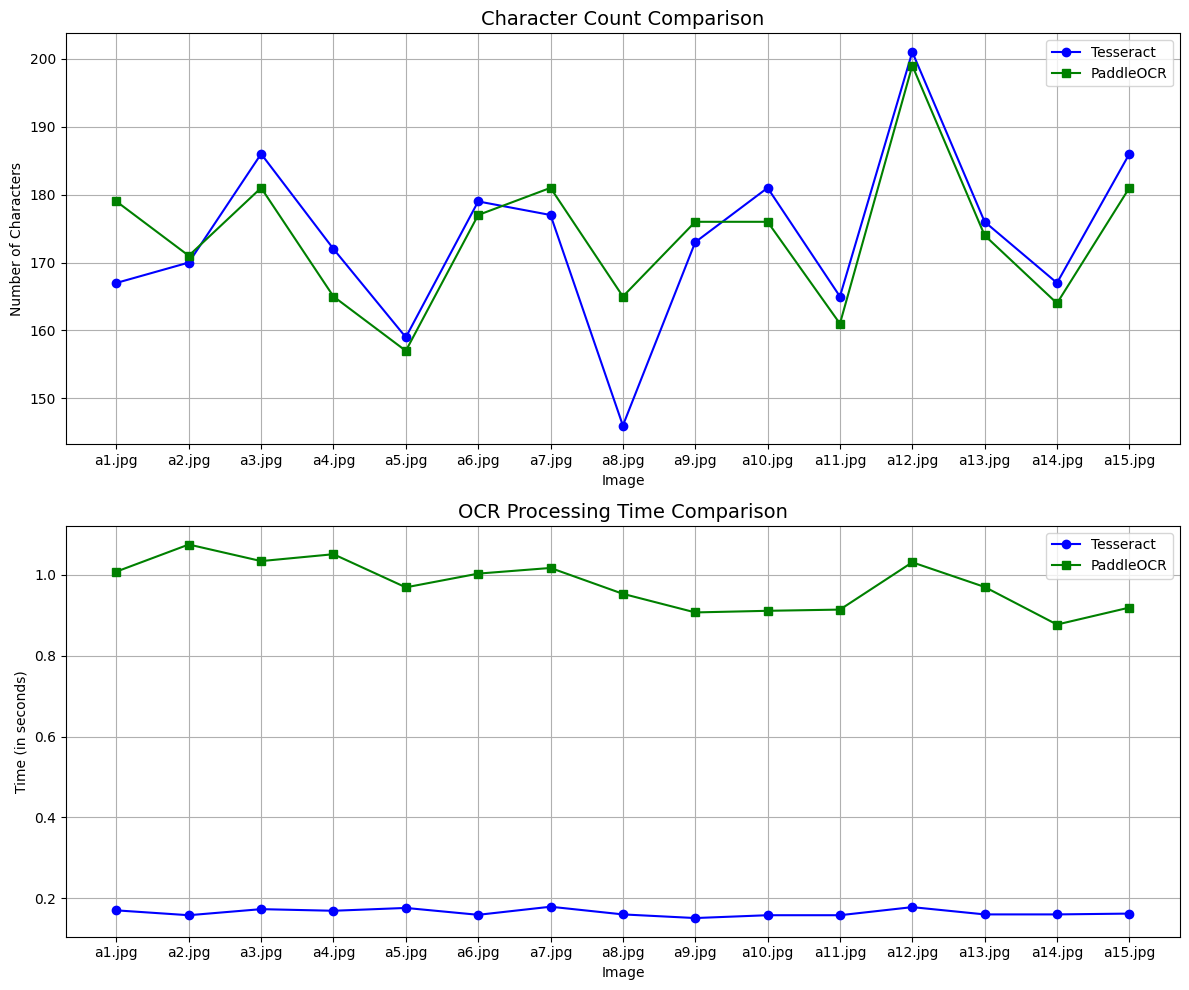

In [29]:
import matplotlib.pyplot as plt

# Set up figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- Character Count Comparison ---
ax1.plot(df_results['Image'], df_results['Tesseract_Chars'], marker='o', label='Tesseract', color='blue')
ax1.plot(df_results['Image'], df_results['PaddleOCR_Chars'], marker='s', label='PaddleOCR', color='green')
ax1.set_title('Character Count Comparison', fontsize=14)
ax1.set_xlabel('Image')
ax1.set_ylabel('Number of Characters')
ax1.legend()
ax1.grid(True)

# --- Time Comparison ---
ax2.plot(df_results['Image'], df_results['Tesseract_Time'], marker='o', label='Tesseract', color='blue')
ax2.plot(df_results['Image'], df_results['PaddleOCR_Time'], marker='s', label='PaddleOCR', color='green')
ax2.set_title('OCR Processing Time Comparison', fontsize=14)
ax2.set_xlabel('Image')
ax2.set_ylabel('Time (in seconds)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
